## Low rank solutions
This notebook looks at different low-rank solutions:
 - How does the the max rank $r$ affect $X_r$?
 - How does different sources interact with $r$?
 - How is convergence of DLRA-CG (early stopping)?

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from fenics import Function, plot
from utils.problem_setup import TestProblemsSetup
from algorithms.cg_solvers import DynamicalLowRankPCG
from algorithms.rsvd_solvers import MatrixFreeRSVD

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SEED = 15
SETUP = TestProblemsSetup(n=64)
PROBLEMS = SETUP.get_test_problems()
PROBLEM_PARAMS = SETUP.problem_params

def plot2(x, pb, *args, **kwargs):
    f = Function(pb['V_h'])
    f.vector()[:] = x
    plot(f, *args, **kwargs)

def plot_multiple_f(
        x_list, pid,
        names=None, fig_name=None, shrink=0,
        layout=None, figsize=None, labelpad=10
    ):
    from utils.colors import CMAP
    from utils.plotting import save_plot
    import matplotlib.patches as patches

    pb = PROBLEMS[pid]
    PBP = PROBLEM_PARAMS[pid]
    width, height = PBP['width'], PBP['height']
    x0s, y0s = PBP['x0'], PBP['y0']

    f_list = []
    for x in x_list:
        f = Function(pb['V_h'])
        f.vector()[:] = x
        f_list.append(f)

    if figsize is None: figsize = (6, 6)
    if names is None: names = ['' for _ in f_list]
    if layout is None: layout = (2, 2)

    fig, axes = plt.subplots(*layout, figsize=figsize)
    
    for ax, func, name in zip(axes.flat, f_list, names):
        plt.sca(ax)
        p = plot(func, cmap=CMAP)
        if shrink != 0: fig.colorbar(p, ax=ax, format="%.2f", shrink=shrink)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(name, labelpad=labelpad)

        for x0, y0 in zip(x0s, y0s):
            square = patches.Rectangle(
                (x0, y0), width, height,
                edgecolor="white",
                facecolor="none"
            )
            ax.add_patch(square)
    
    plt.tight_layout()
    save_plot(fig_name=fig_name)
    plt.show()

In [105]:
pid = 'II'
pb = PROBLEMS[pid]
solutions, errors = [], []

ranks = [5, 10, 15]#, 25, 200]
for i, k in enumerate(ranks):
    rsvd = MatrixFreeRSVD(pb['V_h'])
    rsvd.solve(k=k, seed=SEED + i + 1)
    w = rsvd.weights()
    
    solver = DynamicalLowRankPCG(rsvd, pb['x'])

    x = solver.solve(pb['y'], w,
        lambda_=1e-4, max_iter=5000, max_rank=2, rtol=0, etol=0, seed=SEED,
        restart_every=5, preconditioner='ic-woodbury'
    )
    errors.append(solver.error.copy())
    solutions.append(x)

[##############################] 5000/5000
[##############################] 5000/5000
[##############################] 5000/5000


../../figures/low_rank_effect_of_k_I.png already exists


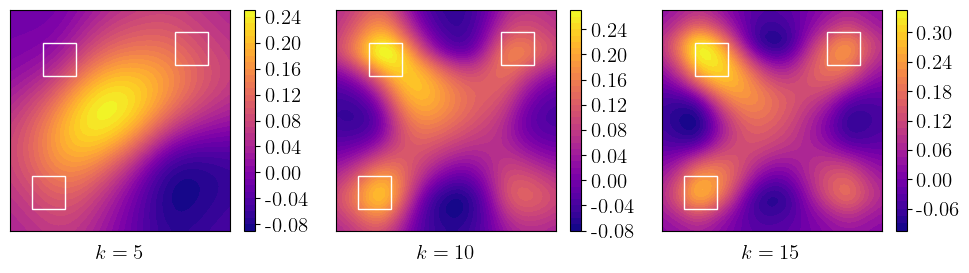

In [106]:
plot_multiple_f(
    solutions, pid=pid, layout=(1,3), figsize=(10,4), shrink=0.62,
    names=('$k = 5$', '$k = 10$', '$k = 15$'),
    fig_name='low_rank_effect_of_k_I'
)

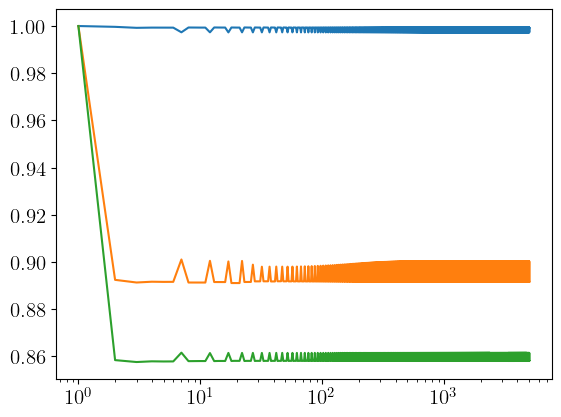

In [108]:
for e in errors:
    plt.semilogx(np.arange(1, len(e)+1), e)